In [34]:
# pip install py_stringmatching
import py_stringmatching as sm

# 1. Initialize the Levenshtein similarity measure
# It is efficient to initialize this once outside the function
lev = sm.Levenshtein()

def calculate_lev_similarity(row, records_df, column):

    try:
        string1 = str(records_df.loc[row['1'], column])
        string2 = str(records_df.loc[row['2'], column])
    except KeyError:
        # Returns 0 if an ID is not found in the reference DataFrame
        return 0.0
    score = lev.get_sim_score(string1, string2)
    
    # Scale to 0-100 to identify "Hard Matches" (duplicates with low scores)
    return score

jac = sm.Jaccard()

def calculate_jac(row, records_df, column, tokenizer):
    try:
        string1 = str(records_df.loc[row['1'], column])
        string2 = str(records_df.loc[row['2'], column])
    except KeyError:
        # Returns 0 if an ID is not found in the reference DataFrame
        return 0.0
    
    x = tokenizer.tokenize(string1)
    y = tokenizer.tokenize(string2)

    score = jac.get_sim_score(x, y)
    
    # Scale to 0-100 to identify "Hard Matches" (duplicates with low scores)
    return score

me = sm.MongeElkan()

def calculate_me(row, records_df, column, tokenizer):
    try:
        string1 = str(records_df.loc[row['1'], column])
        string2 = str(records_df.loc[row['2'], column])
    except KeyError:
        # Returns 0 if an ID is not found in the reference DataFrame
        return 0.0
    
    x = tokenizer.tokenize(string1)
    y = tokenizer.tokenize(string2)

    score = me.get_raw_score(x, y)
    
    # Scale to 0-100 to identify "Hard Matches" (duplicates with low scores)
    return score

In [36]:
import pandas as pd

movies = pd.read_csv("../data/raw/imdb/title_basics.csv")
movies.set_index('tconst', inplace=True)
movie_dups = pd.read_csv("../data/raw/imdb/title_basics_dups.csv")
acts_in = pd.read_csv("../data/raw/imdb/title_principals.csv")

# 2. Compute Levenstein for all labeled duplicates
movie_dups_sorted = movie_dups.copy()
movie_dups_sorted['similarity_score'] = movie_dups.apply(
    calculate_lev_similarity, 
    axis=1, 
    records_df=movies,
    column="primaryTitle"
)

# 3. Sort ascending to find "Hard Matches" 
# (Items labeled as duplicate but with low string similarity)
hard_matches = movie_dups_sorted.sort_values(by='similarity_score', ascending=True)

print("--- Hardest Matches (Ranked by lowest Similarity on attribute: 'primaryTitle') ---")
for _, row in hard_matches.head(20).iterrows():
    r1 = movies.loc[row['1']]
    r2 = movies.loc[row['2']]
    print(f"Score: {row['similarity_score']:.2f} - left: {r1['primaryTitle']}, right: {r2['primaryTitle']}")


--- Hardest Matches (Ranked by lowest Similarity on attribute: 'primaryTitle') ---
Score: 0.56 - left: Jessiel, right: TheJessie
Score: 0.57 - left: Roar, right: TheRoar
Score: 0.57 - left: TheRoar, right: Roar
Score: 0.60 - left: TheRoxanne, right: RoxanneZ
Score: 0.67 - left: TheJessie, right: Jessie
Score: 0.67 - left: HR, right: HRg
Score: 0.67 - left: HR, right: HRg
Score: 0.67 - left: HRi, right: HRg
Score: 0.67 - left: HR, right: HRi
Score: 0.67 - left: HRi, right: HR
Score: 0.69 - left: TheEven Money, right: Even Moneyb
Score: 0.70 - left: TheRoxanne, right: Roxanne
Score: 0.70 - left: TheRoxanne, right: Roxanne
Score: 0.71 - left: TheThe Donut King, right: The Donut King\\
Score: 0.75 - left: 245, right: 245F
Score: 0.75 - left: TheKaspar Hauser, right: Kaspar HauserU
Score: 0.75 - left: Mab, right: Mabw
Score: 0.75 - left: Mab, right: Mabw
Score: 0.75 - left: 999, right: 999e
Score: 0.75 - left: 999, right: 999e


In [37]:
# 2. Compute Jaccard for all labeled duplicates
movie_dups_sorted = movie_dups.copy()
tokenizer = sm.AlphabeticTokenizer()
# tokenizer = sm.AlphanumericTokenizer()
# tokenizer = sm.WhitespaceTokenizer()
# tokenizer = sm.QgramTokenizer(qval=3)
movie_dups_sorted['similarity_score'] = movie_dups.apply(
    calculate_jac, 
    axis=1, 
    records_df=movies,
    column="primaryTitle",
    tokenizer = tokenizer
)

# 3. Sort ascending to find "Hard Matches" 
# (Items labeled as duplicate but with low string similarity)
hard_matches = movie_dups_sorted.sort_values(by='similarity_score', ascending=True)

print("--- Hardest Matches (Ranked by lowest Jaccard Similarity on attribute: 'primaryTitle') ---")
for _, row in hard_matches.head(20).iterrows():
    r1 = movies.loc[row['1']]
    r2 = movies.loc[row['2']]
    print(f"Score: {row['similarity_score']:.2f} - left: {tokenizer.tokenize(r1['primaryTitle'])}, right: {tokenizer.tokenize(r2['primaryTitle'])}")


--- Hardest Matches (Ranked by lowest Jaccard Similarity on attribute: 'primaryTitle') ---
Score: 0.00 - left: ['Airportg'], right: ['Airport']
Score: 0.00 - left: ['Jimeoind'], right: ['Jimeoinr']
Score: 0.00 - left: ['Paddayiw'], right: ['Paddayi']
Score: 0.00 - left: ['Killj'], right: ['Kill']
Score: 0.00 - left: ['FoodographyP'], right: ['Foodography']
Score: 0.00 - left: ['Exit'], right: ['Exitf']
Score: 0.00 - left: ['Holly'], right: ['HollyD']
Score: 0.00 - left: ['CiprianoJ'], right: ['Cipriano']
Score: 0.00 - left: ['ProximityK'], right: ['Proximity']
Score: 0.00 - left: ['Bedrooms'], right: ['Bedroomsg']
Score: 0.00 - left: ['Terminal'], right: ['TerminalC']
Score: 0.00 - left: ['Lilies'], right: ['Liliesf']
Score: 0.00 - left: ['Appooppan'], right: ['AppooppanO']
Score: 0.00 - left: ['OntheShouldersofGiants'], right: ['OntheShouldersofGiantso']
Score: 0.00 - left: ['Caramelle'], right: ['Caramelley']
Score: 0.00 - left: ['GiftgasM'], right: ['GiftgasE']
Score: 0.00 - left: [

In [39]:
# 2. Compute Monge Elkan for all labeled duplicates
movie_dups_sorted = movie_dups.copy()
tokenizer = sm.AlphabeticTokenizer()
# tokenizer = sm.AlphanumericTokenizer()
# tokenizer = sm.WhitespaceTokenizer()
# tokenizer = sm.QgramTokenizer(qval=3)
movie_dups_sorted['similarity_score'] = movie_dups.apply(
    calculate_me, 
    axis=1, 
    records_df=movies,
    column="primaryTitle",
    tokenizer = tokenizer
)

# 3. Sort ascending to find "Hard Matches" 
# (Items labeled as duplicate but with low string similarity)
hard_matches = movie_dups_sorted.sort_values(by='similarity_score', ascending=True)

print("--- Hardest Matches (Ranked by lowest Monge Elkan Similarity on attribute: 'primaryTitle') ---")
for _, row in hard_matches.head(30).iterrows():
    r1 = movies.loc[row['1']]
    r2 = movies.loc[row['2']]
    print(f"Score: {row['similarity_score']:.2f} - left: {tokenizer.tokenize(r1['primaryTitle'])}, right: {tokenizer.tokenize(r2['primaryTitle'])}")


--- Hardest Matches (Ranked by lowest Monge Elkan Similarity on attribute: 'primaryTitle') ---
Score: 0.00 - left: [], right: ['e']
Score: 0.00 - left: ['Roar'], right: ['TheRoar']
Score: 0.00 - left: [], right: ['e']
Score: 0.00 - left: [], right: ['w']
Score: 0.00 - left: [], right: ['F']
Score: 0.00 - left: ['g'], right: ['w']
Score: 0.00 - left: ['TheRoar'], right: ['Roar']
Score: 0.00 - left: ['F'], right: []
Score: 0.00 - left: ['g'], right: []
Score: 0.00 - left: [], right: ['e']
Score: 0.00 - left: [], right: ['w']
Score: 0.00 - left: ['F'], right: []
Score: 0.00 - left: [], right: ['g']
Score: 0.50 - left: ['h', 'Z'], right: ['h']
Score: 0.50 - left: ['One', 'r'], right: ['One']
Score: 0.50 - left: ['One', 'H'], right: ['One']
Score: 0.50 - left: ['Ass', 'Worship', 'w'], right: ['TheAss', 'Worship']
Score: 0.50 - left: ['h', 'Z'], right: ['h', 'D']
Score: 0.50 - left: ['One', 'r'], right: ['One', 'H']
Score: 0.50 - left: ['Gramsci', 'W'], right: ['Gramsci']
Score: 0.67 - left:

In [53]:
import random

def find_hard_non_matches(records_df, duplicates_df, sample_size=1000):
    """
    Finds non-duplicate pairs with high similarity (Hard Non-Matches).
    """
    # 1. Create a set of known duplicates for fast lookup (ground truth)
    # We store both (A, B) and (B, A) to ensure we don't pick them as non-matches
    known_dups = set()
    for _, row in movie_dups.iterrows():
        known_dups.add((row['1'], row['2']))
        known_dups.add((row['2'], row['1']))

    # 2. Blocking: Group by 'year' to find plausible non-match candidates
    # This prevents us from comparing "The Karate Kid" to "Finding Nemo"
    candidates = []
    grouped = movies.groupby('startYear')

    for year, group in grouped:
        if len(group) < 2:
            continue
            
        # Get IDs in this year block
        ids = group.index.tolist()
        
        # Sample pairs within the same year to find "Hard Non-Matches"
        # Increase 'k' if you want a more exhaustive search
        for _ in range(min(len(ids) * 2, 500)): 
            idx1, idx2 = random.sample(ids, 2)
            
            # Only proceed if they are NOT known duplicates
            if (idx1, idx2) not in known_dups:
                candidates.append((idx1, idx2))

    # 3. Calculate similarity for these candidates
    results = []
    for left_id, right_id in candidates[:sample_size]:
        r1 = movies.loc[left_id]
        r2 = movies.loc[right_id]
        
        # me = sm.MongeElkan(sim_func=sm.Levenshtein().get_sim_score)
        me = sm.Levenshtein()
        # title_sim = me.get_raw_score(tokenizer.tokenize(r1['primaryTitle']),tokenizer.tokenize(r2['primaryTitle']))
        title_sim = me.get_sim_score(r1['primaryTitle'],r2['primaryTitle'])
        
        results.append({
            'left_id': left_id,
            'right_id': right_id,
            'sim_score': title_sim,
            'left_title': r1['primaryTitle'],
            'right_title': r2['primaryTitle'],
            'year': r1['startYear']
        })

    # 4. Sort descending: High similarity + Not Duplicates = Hard Non-Matches
    hard_non_matches = pd.DataFrame(results).sort_values(by='sim_score', ascending=False)
    
    return hard_non_matches

# Run the detection
hard_non_matches = find_hard_non_matches(movies, movie_dups)

print("--- Top 10 Hard Non-Matches (High Similarity, but NOT Duplicates) ---")
print(hard_non_matches[['left_title', 'right_title', 'sim_score']].head(10))

--- Top 10 Hard Non-Matches (High Similarity, but NOT Duplicates) ---
                           left_title                       right_title  \
960                         The Swapq                         The Devil   
956                         The Swapq                         The Devil   
971                           Potiche                            Eunice   
254                 Lola the Coalgirl                       Sumaithangi   
267                 Lola the Coalgirl                       Sumaithangi   
695              The Towering Inferno     The Education of Sonny Carson   
569           The Island of Dr Moreau  The Golden Claws of the Cat Girl   
568  The Golden Claws of the Cat Girl           The Island of Dr Moreau   
573  The Golden Claws of the Cat Girl           The Island of Dr Moreau   
565           The Island of Dr Moreau  The Golden Claws of the Cat Girl   

     sim_score  
960   0.444444  
956   0.444444  
971   0.428571  
254   0.352941  
267   0.352941  
69

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_difficulty(movies_df, junction_df, duplicates_df, top_k=10):
    # 1. Prepare "Flattened" Record Strings for TF-IDF
    # Combine title and any other text features into one string
    # movies_df['combined_text'] = movies_df['primaryTitle'].astype(str) + " " + movies_df.get('genres', '')
    movies_df['combined_text'] = movies_df['primaryTitle'].astype(str) 
    
    tfidf = TfidfVectorizer(stop_words='english', analyzer='char_wb', ngram_range=(3,3))
    tfidf_matrix = tfidf.fit_transform(movies_df['combined_text'])
    
    # 2. Map Neighborhoods (Junction Table: movie_id -> [actor_ids])
    # Assuming junction_df has columns ['movie_id', 'neighbor_id']
    neighborhoods = junction_df.groupby('tconst')['nconst'].apply(set).to_dict()

    # 3. Create Ground Truth Set
    known_dups = set()
    for _, row in duplicates_df.iterrows():
        # Store as sorted tuple to handle (A,B) and (B,A) identically
        pair = tuple(sorted((row['1'], row['2'])))
        known_dups.add(pair)

    results = []
    movie_ids = movies_df.index.tolist()

    # 4. For a sample of movies, find the most similar others
    for i, m1_id in enumerate(movie_ids):
        # Get cosine similarity of this movie against ALL others
        sim_vector = cosine_similarity(tfidf_matrix[i], tfidf_matrix).flatten()
        
        # Get indices of top_k most similar (excluding itself)
        related_indices = sim_vector.argsort()[-(top_k+1):-1][::-1]
        
        for idx in related_indices:
            m2_id = movie_ids[idx]
            
            # --- THE CRITICAL CHECKS ---
            # 1. Identity Check: Skip if it's the same record
            if m1_id == m2_id:
                continue
            
            # 2. Symmetry Check: To avoid (A,B) and (B,A) duplicates in our results,
            # we only process if ID1 < ID2 (lexicographical order)
            if str(m1_id) >= str(m2_id):
                continue
            
            score = sim_vector[idx]
            
            # Neighborhood Jaccard Similarity
            n1 = neighborhoods.get(m1_id, set())
            n2 = neighborhoods.get(m2_id, set())
            
            intersection = len(n1.intersection(n2))
            union = len(n1.union(n2))
            jaccard = intersection / union if union > 0 else 0
            
            is_dup = (m1_id, m2_id) in known_dups or (m2_id, m1_id) in known_dups
            
            results.append({
                'id1': m1_id, 'id2': m2_id,
                'string_sim': score,
                'neighbor_sim': jaccard,
                'is_duplicate': is_dup
            })

    return pd.DataFrame(results)

# Run Analysis
diff_df = evaluate_difficulty(movies, acts_in, movie_dups)

# --- FINDING THE HARD CASES ---

# 1. Hard Matches (Duplicates with low similarity)
hard_matches = diff_df[diff_df['is_duplicate']].sort_values(['string_sim', 'neighbor_sim']).head(30)
display(hard_matches)

# 2. Hard Non-Matches (High similarity, but NOT duplicates)
hard_non_matches = diff_df[~diff_df['is_duplicate']].sort_values('string_sim', ascending=False).head(10)
display(hard_non_matches)

# 3. Neighborhood Conflict (Looks similar, but neighbors are totally different)
neighborhood_conflict = diff_df[(diff_df['string_sim'] > 0.4) & (diff_df['string_sim'] < 0.99)& (diff_df['neighbor_sim'] == 0)].sort_values('string_sim', ascending=False).head(10)
display(neighborhood_conflict)

/opt/anaconda3/envs/deepcem311/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


,id1,id2,string_sim,neighbor_sim,is_duplicate
2446,tt12545225,tt12545226,0.380648,0.250000,True
10245,tt12545224,tt12545225,0.411854,0.000000,True
11095,tt0933344,tt12545225,0.411854,0.200000,True
10016,tt12531252,tt12531253,0.427966,0.000000,True
10163,tt12531253,tt6103096,0.427966,0.000000,True
10548,tt12531251,tt12531253,0.427966,0.000000,True
10244,tt12545224,tt12545226,0.473743,0.200000,True
11094,tt0933344,tt12545226,0.473743,0.500000,True
6002,tt12532974,tt12532975,0.480858,0.000000,True
5904,tt12541274,tt12541275,0.497622,0.083333,True


,id1,id2,string_sim,neighbor_sim,is_duplicate
6867,tt12539151,tt7941920,0.947616,0.0,False
7282,tt12539152,tt7941920,0.947616,0.0,False
5263,tt12536014,tt2014365,0.947616,0.0,False
5262,tt12536014,tt12539152,0.947616,0.0,False
5261,tt12536014,tt12539153,0.947616,0.0,False
10424,tt2014365,tt7941920,0.947616,0.0,False
11235,tt12539153,tt7941920,0.947616,0.0,False
5264,tt12536014,tt12539151,0.947616,0.0,False
4415,tt1202151,tt1285278,0.790551,0.0,False
13007,tt12541277,tt1285278,0.790551,0.0,False


,id1,id2,string_sim,neighbor_sim,is_duplicate
12921,tt12535275,tt3811966,0.976089,0.0,True
12922,tt12535275,tt12535276,0.976089,0.0,True
6307,tt12537300,tt12537301,0.965181,0.0,True
13408,tt12542408,tt12542410,0.963439,0.0,True
3860,tt12533048,tt12533049,0.961992,0.0,True
10228,tt12531998,tt12531999,0.960621,0.0,True
3117,tt12545610,tt12545611,0.959776,0.0,True
3116,tt12545610,tt2574518,0.959776,0.0,True
10199,tt12545609,tt12545610,0.959776,0.0,True
10053,tt12535537,tt12535538,0.959091,0.0,True


In [6]:
from collections import defaultdict
import pickle
from typing import List, Set, Tuple

import matplotlib.pyplot as plt

def calc_sizes(components):

    occs = defaultdict(int)
    comps_indexed_by_size = defaultdict(list)
    for c in components:
        size = len(c)
        occs[size] = occs[size] + 1
        comps_indexed_by_size[size].append(c)
    return occs, comps_indexed_by_size

def plot_binned_sizes(occs):
    bins = {
        "Size 1": 0,
        "Size 2": 0,
        "Size 3-5": 0,
        "Size 6-10": 0,
        "Size 11-50": 0,
        "Size 51+": 0
    }

    for size, count in occs.items():
        if size == 1: bins["Size 1"] += count
        elif size == 2: bins["Size 2"] += count
        elif size <= 5: bins["Size 3-5"] += count
        elif size <= 10: bins["Size 6-10"] += count
        elif size <= 50: bins["Size 11-50"] += count
        else: bins["Size 51+"] += count

    plt.figure(figsize=(10, 6))
    plt.bar(bins.keys(), bins.values(), color='teal')
    plt.xticks(rotation=45)
    plt.ylabel("Number of Components")
    plt.title("Binned Component Size Distribution")
    plt.tight_layout()
    plt.show()

def get_name_movie_dist(comps_indexed_by_size, size):
    for idx, s in enumerate(comps_indexed_by_size[size]):
        nm = 0
        tt = 0                   
        for e in s:
            if e.startswith('nm'):
                nm += 1
            if e.startswith('tt'):
                tt += 1

        print(f"For component  with size {size}:")
        print(f"Index {idx}: Amount Names: {nm}, amount movies: {tt}")
        
def plot_size_dist(occs, name):
    sorted_keys = sorted(occs.keys())
    names = [int(k) for k in sorted_keys]
    values = [int(occs[k]) for k in sorted_keys]
    print(names)
    print(values)

    plt.figure(figsize=(10, 5))
        
    # 3. Use bar() with explicit alignment
    plt.bar(names, values, align='center', width=0.8)

    plt.xlabel('Component Size')
    plt.ylabel('Counts')
    plt.title(f"Component Size Distribution {name}")

    plt.show()


# All Components

[defaultdict(<class 'set'>, {'movie': {'tt0800080', 'tt12541591', 'tt12541592'}, 'all_nodes': {'nm0672015', 'nm0456158', 'tt12541591', 'nm0001570', 'nm21965472', 'nm0000619', 'nm21965473', 'nm0504642', 'nm0000239', 'nm0032696', 'nm0000458', 'tt0800080', 'nm0498278', 'nm21965474', 'nm21965471', 'nm0270559', 'tt12541592'}, 'name': {'nm0672015', 'nm0456158', 'nm0001570', 'nm21965472', 'nm0000619', 'nm21965473', 'nm0504642', 'nm0000239', 'nm0032696', 'nm0000458', 'nm0498278', 'nm21965474', 'nm21965471', 'nm0270559'}}), defaultdict(<class 'set'>, {'movie': {'tt12545172', 'tt2279927', 'tt12545170', 'tt12545171'}, 'all_nodes': {'tt12545172', 'nm0619834', 'nm2238631', 'nm2241615', 'nm4921980', 'nm2203235', 'nm21968968', 'tt12545171', 'tt12545170', 'nm2207577', 'nm2245266', 'nm2246020', 'nm3972986', 'nm21968969', 'tt2279927', 'nm4933605'}, 'name': {'nm0619834', 'nm2238631', 'nm2241615', 'nm4921980', 'nm2203235', 'nm21968968', 'nm2207577', 'nm2245266', 'nm2246020', 'nm3972986', 'nm21968969', 'nm

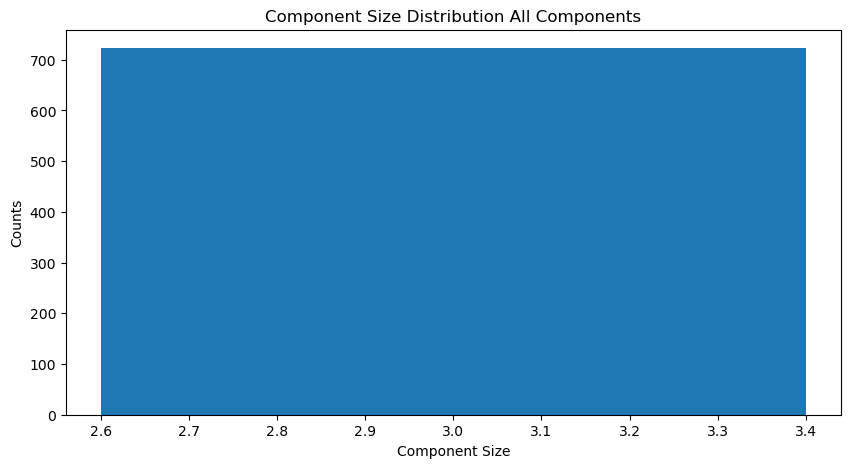

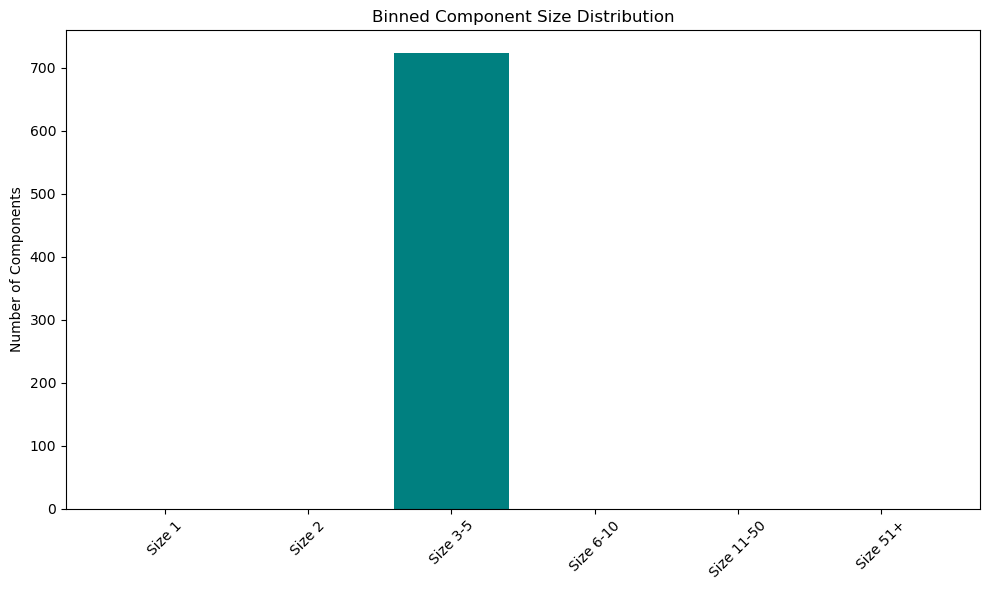

For component  with size 3:
Index 0: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 1: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 2: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 3: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 4: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 5: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 6: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 7: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 8: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 9: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 10: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 11: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 12: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 13: Amount Names: 0, amount movies: 0
Fo

In [7]:
with open('../pickles/imdb_hard_components.pickle', 'rb') as f:
    components: list[Set[str]] = pickle.load(f)

print(components)
occs, comps_by_size = calc_sizes(components)

plot_size_dist(occs, "All Components")
plot_binned_sizes(occs)
for key in occs.keys(): 
    get_name_movie_dist(comps_by_size, key)


# Per Split

In [8]:
with open('../pickles/imdb_hard_splits.pickle', 'rb') as f:
    splits: Tuple[List[Set[str]], List[Set[str]], List[Set[str]]] = pickle.load(f)


## TRAIN

[defaultdict(<class 'set'>, {'movie': {'tt0393068', 'tt12543978', 'tt0195054', 'tt0161506', 'tt12538665', 'tt12543980', 'tt12541448', 'tt0161597', 'tt12534925', 'tt0393824', 'tt12534926', 'tt12538664', 'tt12531639', 'tt12540778', 'tt12541447', 'tt12540322', 'tt12540779', 'tt12531638', 'tt0180492', 'tt0328285', 'tt12540780', 'tt12531640', 'tt12543979', 'tt12540323'}, 'all_nodes': {'nm0752796', 'nm0012637', 'nm0001000', 'nm0214150', 'tt0161506', 'tt12538665', 'tt12534925', 'tt12534926', 'nm2403293', 'nm1477702', 'nm3403758', 'nm0038971', 'nm0107613', 'tt0180492', 'nm21967787', 'nm0290329', 'nm21964168', 'tt12543979', 'nm0660467', 'nm2956452', 'nm0206799', 'nm0604517', 'tt12543978', 'tt0195054', 'nm21955439', 'nm0094217', 'tt12543980', 'tt0161597', 'tt0393824', 'nm21965343', 'nm21955435', 'nm0000259', 'nm0584489', 'nm0018732', 'nm1905666', 'tt12541447', 'tt12540322', 'tt12540779', 'nm0640033', 'nm0237641', 'nm0950045', 'nm0227585', 'nm0209615', 'tt12531640', 'nm0124973', 'nm21967788', 'nm

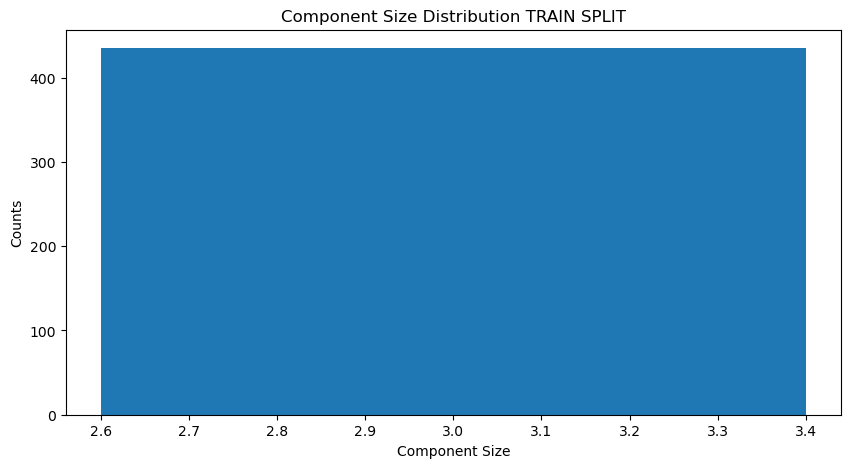

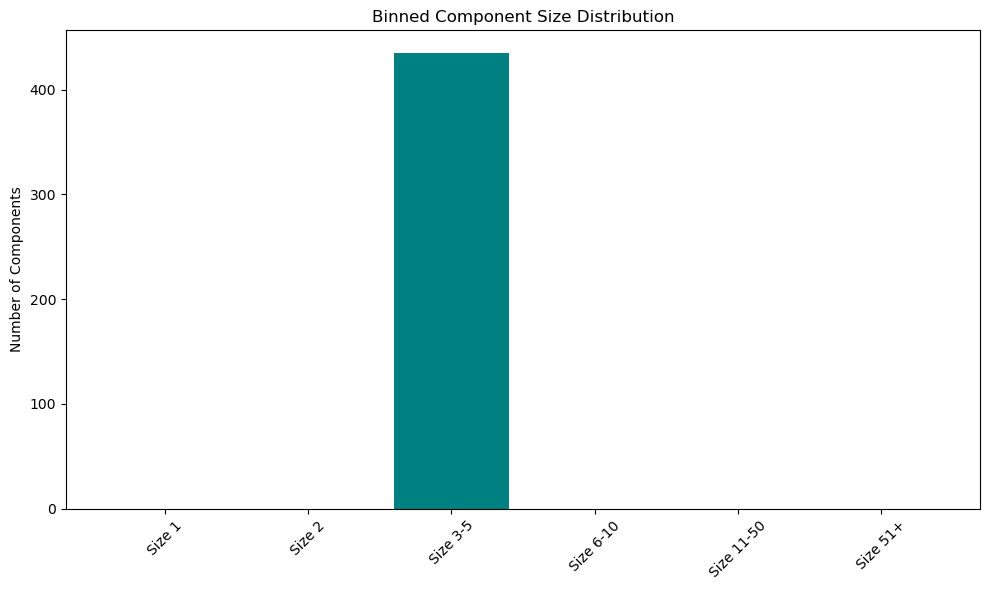

For component  with size 3:
Index 0: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 1: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 2: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 3: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 4: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 5: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 6: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 7: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 8: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 9: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 10: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 11: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 12: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 13: Amount Names: 0, amount movies: 0
Fo

In [9]:

components: list[Set[str]] = splits[0]

print(components)
occs, comps_by_size = calc_sizes(components)

plot_size_dist(occs, "TRAIN SPLIT")
plot_binned_sizes(occs)
for key in occs.keys(): 
    get_name_movie_dist(comps_by_size, key)


## Validation

[defaultdict(<class 'set'>, {'movie': {'tt3526322', 'tt12541688', 'tt12541687'}, 'all_nodes': {'nm21965564', 'nm6283388', 'nm21965563', 'nm0961594', 'nm21965561', 'tt12541688', 'tt3526322', 'tt12541687', 'nm21965562', 'nm6283387', 'nm0924502', 'nm0671980', 'nm1318412', 'nm1167928', 'nm0415529'}, 'name': {'nm21965564', 'nm6283388', 'nm21965563', 'nm0961594', 'nm21965561', 'nm0924502', 'nm21965562', 'nm6283387', 'nm0671980', 'nm1318412', 'nm1167928', 'nm0415529'}}), defaultdict(<class 'set'>, {'movie': {'tt12545321', 'tt12545320', 'tt0190244'}, 'all_nodes': {'nm21969111', 'tt12545321', 'nm0937403', 'tt12545320', 'nm0146720', 'tt0190244', 'nm0210460', 'nm0127758', 'nm0858253', 'nm0855892', 'nm0049169', 'nm0056435', 'nm21969110', 'nm0276910', 'nm0195882'}, 'name': {'nm21969111', 'nm0937403', 'nm0146720', 'nm0210460', 'nm0127758', 'nm0858253', 'nm0855892', 'nm0049169', 'nm0056435', 'nm21969110', 'nm0276910', 'nm0195882'}}), defaultdict(<class 'set'>, {'movie': {'tt12535777', 'tt12535776', '

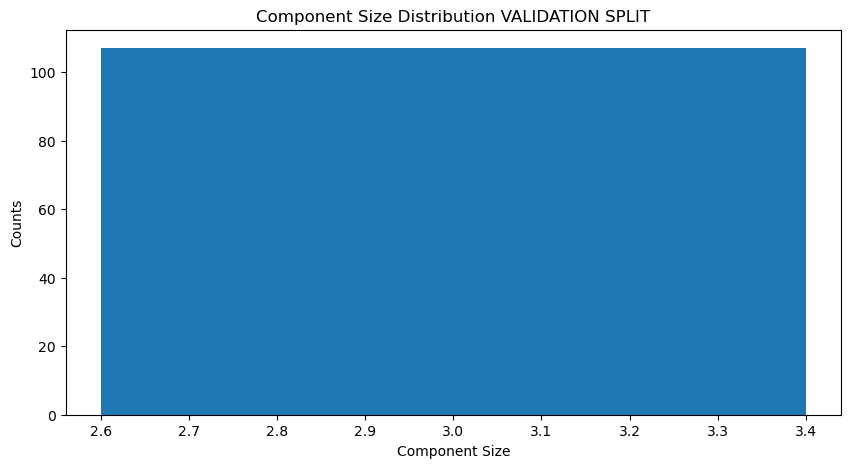

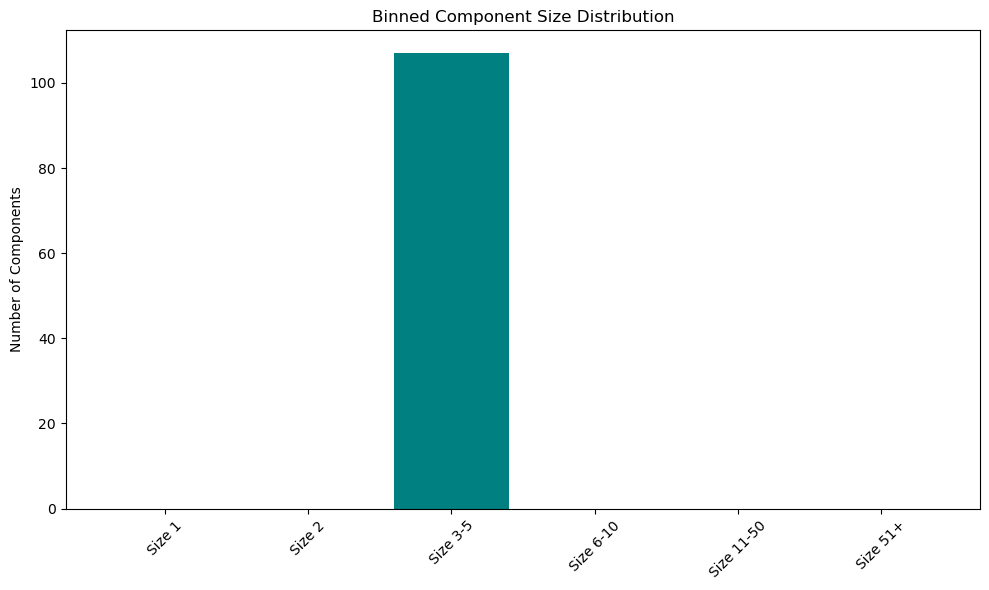

For component  with size 3:
Index 0: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 1: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 2: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 3: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 4: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 5: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 6: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 7: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 8: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 9: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 10: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 11: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 12: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 13: Amount Names: 0, amount movies: 0
Fo

In [10]:
components: list[Set[str]] = splits[1]

print(components)
occs, comps_by_size = calc_sizes(components)

plot_size_dist(occs, "VALIDATION SPLIT")
plot_binned_sizes(occs)
for key in occs.keys(): 
    get_name_movie_dist(comps_by_size, key)


## Test

[defaultdict(<class 'set'>, {'movie': {'tt0043680', 'tt12545207', 'tt12545208'}, 'all_nodes': {'nm0896533', 'nm21969008', 'nm0366942', 'nm0918659', 'nm0105462', 'nm21969007', 'tt0043680', 'tt12545207', 'nm21969006', 'nm0113284', 'nm0861703', 'nm0000011', 'tt12545208', 'nm0004864', 'nm0836328', 'nm0000856'}, 'name': {'nm0896533', 'nm21969008', 'nm0366942', 'nm0918659', 'nm0105462', 'nm21969007', 'nm0836328', 'nm0861703', 'nm21969006', 'nm0113284', 'nm0000011', 'nm0004864', 'nm0000856'}}), defaultdict(<class 'set'>, {'movie': {'tt12542323', 'tt12542324', 'tt1047812', 'tt12542322'}, 'all_nodes': {'nm2677225', 'nm2679040', 'tt12542324', 'tt1047812', 'nm2677223', 'nm21966190', 'nm0736835', 'nm21966191', 'nm2679277', 'nm21966192', 'tt12542323', 'nm1403157', 'nm21966193', 'nm21966194', 'nm1473037', 'tt12542322'}, 'name': {'nm2677225', 'nm2679040', 'nm2677223', 'nm21966190', 'nm0736835', 'nm21966191', 'nm2679277', 'nm21966192', 'nm1403157', 'nm21966193', 'nm21966194', 'nm1473037'}}), defaultdi

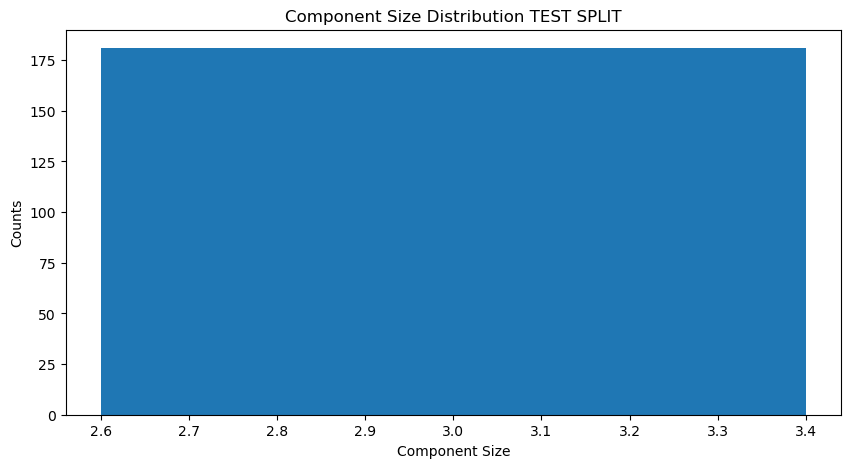

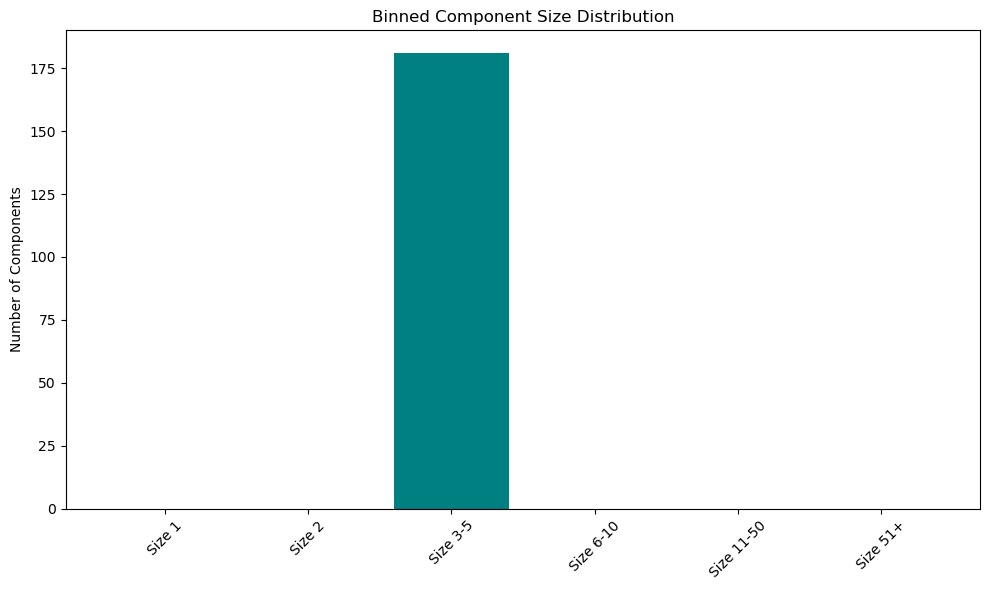

For component  with size 3:
Index 0: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 1: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 2: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 3: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 4: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 5: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 6: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 7: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 8: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 9: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 10: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 11: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 12: Amount Names: 0, amount movies: 0
For component  with size 3:
Index 13: Amount Names: 0, amount movies: 0
Fo

In [11]:
components: list[Set[str]] = splits[2]

print(components)
occs, comps_by_size = calc_sizes(components)

plot_size_dist(occs, "TEST SPLIT")
plot_binned_sizes(occs)
for key in occs.keys(): 
    get_name_movie_dist(comps_by_size, key)


In [12]:
with open('../pickles/imdb_hard_stats.pickle', 'rb') as f:
    df_stats: pd.DataFrame = pickle.load(f)

print(df_stats.head())
df_stats['all_nodes_nodes'].describe()

   comp_id  type_count  movie_nodes  movie_clusters  movie_dupe_count  \
0        0           3            3               1                 2   
1        0           3            3               1                 2   
2        0           3            3               1                 2   
3        1           3            4               1                 3   
4        1           3            4               1                 3   

   all_nodes_nodes  name_nodes  name_clusters  name_dupe_count  
0               17          14             10                4  
1               17          14             10                4  
2               17          14             10                4  
3               16          12             10                2  
4               16          12             10                2  


count    2169.000000
mean       15.585062
std         8.388474
min         4.000000
25%        12.000000
50%        15.000000
75%        17.000000
max       100.000000
Name: all_nodes_nodes, dtype: float64

In [13]:
CONFIGS = ["movie", "name"]
df_stats[[f"{c}_nodes" for c in CONFIGS]].sum()

movie_nodes     8466
name_nodes     25338
dtype: int64

In [14]:
# Duplicate Density
# High Ratio -> Duplicate heavy. 
round(float(df_stats['movie_dupe_count'].sum() / df_stats['movie_nodes'].sum()),2)

0.72

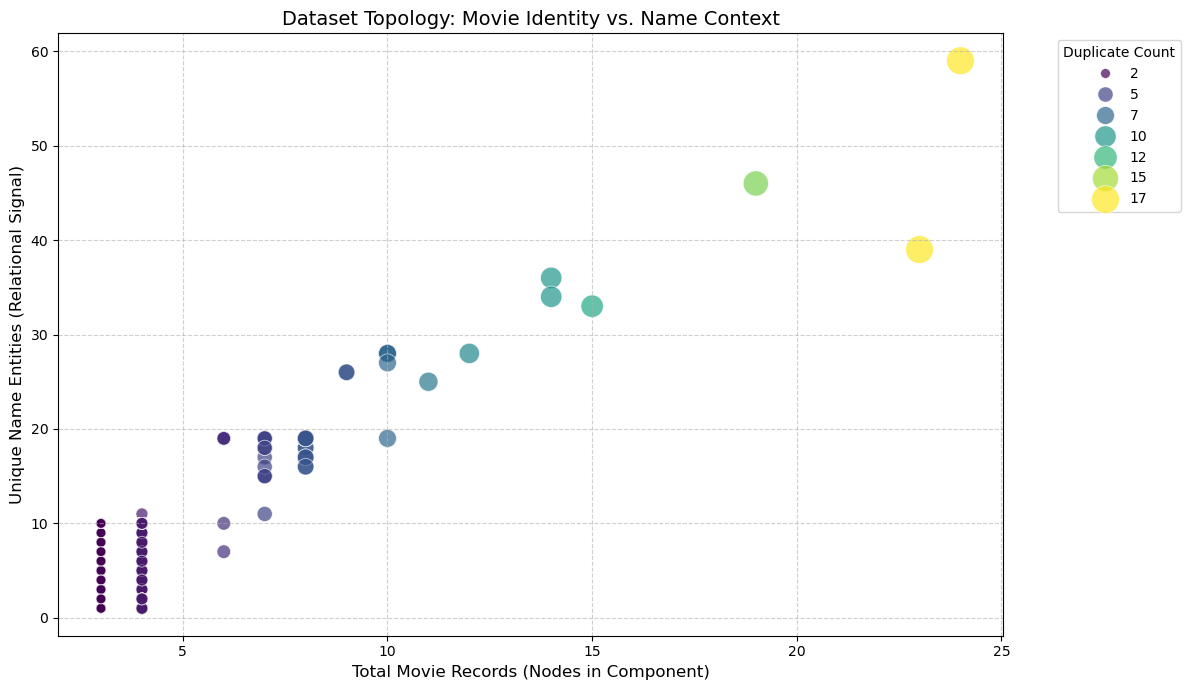

In [19]:
def plot_cem_topology(df_stats, primary="movie", relation="name"):
    # 1. Clean the data: Get one row per component
    # Since your script appended a row for every entity type, we drop duplicates
    df_clean = df_stats.drop_duplicates(subset=['comp_id'])
    
    # 2. Define our axes
    # Identity complexity: How many duplicate records for one entity
    x_col = f"{primary}_nodes" 
    # Relational signal: How many unique related entities provide context
    y_col = f"{relation}_clusters"
    
    plt.figure(figsize=(12, 7))
    
    # 3. Create the Scatter Plot
    # We use 'hue' to show how many 'hard' duplicates (dupe_count) exist
    scatter = sns.scatterplot(
        data=df_clean,
        x=x_col,
        y=y_col,
        size=f"{primary}_dupe_count",
        hue=f"{primary}_dupe_count",
        palette="viridis",
        sizes=(50, 400),
        alpha=0.7
    )
    
    # 4. Formatting for your Advisor
    plt.title(f"Dataset Topology: {primary.capitalize()} Identity vs. {relation.capitalize()} Context", fontsize=14)
    plt.xlabel(f"Total {primary.capitalize()} Records (Nodes in Component)", fontsize=12)
    plt.ylabel(f"Unique {relation.capitalize()} Entities (Relational Signal)", fontsize=12)
    plt.legend(title="Duplicate Count", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Run it with your data
plot_cem_topology(df_stats, primary="movie", relation="name")